# Chess AI Demo Notebook

This notebook provides a presentation-friendly walkthrough of the project.

It covers:
- the project goal
- the current search and evaluation approach
- how to launch the GUI demo
- how to run automated experiments
- how to inspect CSV results and generated plots


## Project Overview

This project implements a chess-playing AI using classical adversarial search.

Current implemented components:
- board representation and legal move generation with `python-chess`
- depth-limited Minimax
- Alpha-Beta pruning
- heuristic evaluation using weighted material, positional, center-control, pawn-structure, and king-safety terms
- Human vs AI desktop GUI
- Human vs AI CLI fallback
- automated self-play experiments
- CSV-based metric collection
- runtime and node-expansion plots


In [12]:
from pathlib import Path

project_root = Path.cwd()
project_root

WindowsPath('c:/Users/eli.lawrence/Documents/CPTS440_AIChessPlayingAgent')

In [13]:
important_files = [
    'main.py',
    'gui.py',
    'cli.py',
    'ai.py',
    'evaluate.py',
    'experiment.py',
    'plot_results.py',
    'README.md',
]

{name: (project_root / name).exists() for name in important_files}

{'main.py': True,
 'gui.py': True,
 'cli.py': True,
 'ai.py': True,
 'evaluate.py': True,
 'experiment.py': True,
 'plot_results.py': True,
 'README.md': True}

## Search and Evaluation

The current chess engine uses:
- `minimax()` for depth-limited adversarial search
- `alphabeta()` for the pruned version used in the GUI and experiments
- `evaluate()` to score board states from White's perspective

The evaluation function currently combines:
- material balance
- piece-square table bonuses for positional play
- mobility
- center attack and center occupation
- pawn structure penalties
- bishop pair bonus
- king safety and castling bonuses
- checkmate and draw handling


In [14]:
import chess

from ai import alphabeta
from evaluate import evaluate

board = chess.Board()
print(board)
print('\nInitial evaluation:', evaluate(board))
print('The refined heuristic now includes material, piece-square tables, mobility, center control, pawn structure, and king safety.')

score, move = alphabeta(
    board,
    depth=1,
    alpha=float('-inf'),
    beta=float('inf'),
    maximizing_player=True,
)

print('Suggested depth-1 move for White:', move)
print('Score:', score)

r n b q k b n r
p p p p p p p p
. . . . . . . .
. . . . . . . .
. . . . . . . .
. . . . . . . .
P P P P P P P P
R N B Q K B N R

Initial evaluation: 0
The refined heuristic now includes material, piece-square tables, mobility, center control, pawn structure, and king safety.
Suggested depth-1 move for White: e2e4
Score: 70


## GUI Demo

The main project demo is the desktop GUI.

Run it from a terminal with:

```bash
python main.py
```

Current GUI features:
- Human vs AI mode
- AI vs AI mode
- adjustable search depth
- separate White and Black AI depths in AI vs AI mode
- New Game and Undo Last Move
- Start Auto Play / Stop Auto Play
- Play One Turn for controlled AI-vs-AI stepping


In [15]:
launch_command = 'python main.py'
print('Launch the GUI with:', launch_command)

Launch the GUI with: python main.py


## Automated Experiments

The experiment runner supports multiple algorithms, depths, and trials, and writes one CSV row per run.

For the clearest comparison plots, run both `alphabeta` and `minimax` into the same CSV file.

Example command:

```bash
python experiment.py --algorithms alphabeta minimax --depths 1 2 3 --trials 3 --output results.csv
```


In [16]:
import subprocess
import sys

demo_results = project_root / 'demo_results.csv'

command = [
    sys.executable,
    'experiment.py',
    '--algorithms', 'alphabeta', 'minimax',
    '--depths', '1', '2',
    '--trials', '1',
    '--output', str(demo_results),
]

print('Prepared demo experiment command:')
print(' '.join(command))
# Uncomment the next two lines to run the demo experiment.
# completed = subprocess.run(command, check=True, capture_output=True, text=True)
# print(completed.stdout)

Prepared demo experiment command:
c:\python313\python.exe experiment.py --algorithms alphabeta minimax --depths 1 2 --trials 1 --output c:\Users\eli.lawrence\Documents\CPTS440_AIChessPlayingAgent\demo_results.csv


## Inspect Results CSV

The CSV rows include:
- algorithm
- trial
- depth
- moves
- result
- time_seconds
- nodes
- avg_time_per_move
- avg_nodes_per_move


In [20]:
import csv

results_path = project_root / 'results.csv'

if results_path.exists():
    with results_path.open(newline='') as file:
        rows = list(csv.DictReader(file))
    print(f'Loaded {len(rows)} result rows from {results_path.name}')
    rows[:3]
else:
    print('results.csv not found yet. Run experiment.py first.')

Loaded 2 result rows from results.csv


## Generate Plots

The plotting script reads the CSV and aggregates average runtime and nodes by algorithm and depth.

If the CSV contains both `alphabeta` and `minimax`, each graph will draw both algorithms on the same axes for direct visual comparison.

Example command:

```bash
python plot_results.py --input results.csv
```


In [21]:
plot_command = [sys.executable, 'plot_results.py', '--input', 'results.csv']
print('Prepared plot command:')
print(' '.join(plot_command))
# Uncomment the next two lines to generate plots from results.csv.
# completed = subprocess.run(plot_command, check=True, capture_output=True, text=True)
# print(completed.stdout)

Prepared plot command:
c:\python313\python.exe plot_results.py --input results.csv


Displaying runtime_vs_depth.png


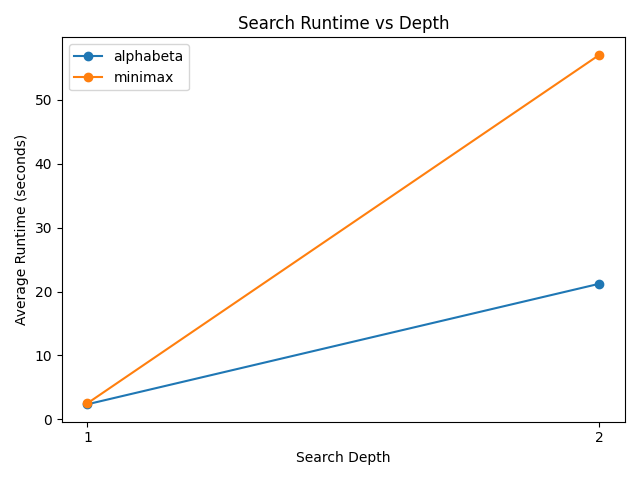

Displaying nodes_vs_depth.png


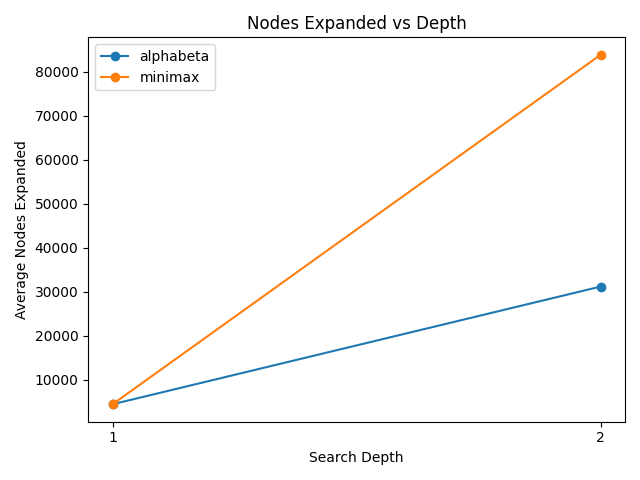

In [24]:
from IPython.display import Image, display

for image_name in ['runtime_vs_depth.png', 'nodes_vs_depth.png']:
    image_path = project_root / image_name
    if image_path.exists():
        print(f'Displaying {image_name}')
        display(Image(filename=str(image_path)))
    else:
        print(f'{image_name} not found yet.')

## Demo Talking Points

A short live demo can highlight three things:
1. The chess AI works interactively in the GUI.
2. The project supports AI-vs-AI self-play and controlled stepping.
3. The system produces measurable experimental results and graphs.
4. The evaluation function is now more refined and tunable than a simple material-only baseline.

That combination shows both the search engine and the systems-integration work behind the project.